# EDA 3. Productie panouri solare - centrala din India (Plant_1)

**Set de date:** doua fisiere de la o centrala fotovoltaica din India:
- `Plant_1_Generation_Data.csv` - puterea produsa la nivel de invertor (DC + AC), la 15 minute.
- `Plant_1_Weather_Sensor_Data.csv` - temperatura ambient, temperatura modul, iradiatie solara.

**Scop:** intelegerea dependentei dintre iradiere/temperatura si puterea generata, identificarea anomaliilor si alegerea features pentru modelul predictiv de productie solara.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing.loader import load_solar_india, merge_solar
from src.utils.plotting import (
    setup_style,
    plot_distribution,
    plot_correlation_heatmap,
    PALETA,
)

setup_style()

## 1. Incarcarea datelor

Datele de generare contin un rand pentru fiecare invertor x timestamp (mai multe invertoare pe centrala). Datele meteo provin de la un singur senzor, deci au mai putine randuri.

In [2]:
gen, weather = load_solar_india()

print(f'Generare: {gen.shape}, perioada {gen["DATE_TIME"].min()} -> {gen["DATE_TIME"].max()}')
print(f'Numar invertoare: {gen["SOURCE_KEY"].nunique()}')
print(f'\nMeteo: {weather.shape}, perioada {weather["DATE_TIME"].min()} -> {weather["DATE_TIME"].max()}')

Generare: (68778, 7), perioada 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Numar invertoare: 22

Meteo: (3182, 6), perioada 2020-05-15 00:00:00 -> 2020-06-17 23:45:00


**Interpretare:** datele acopera aproximativ 34 de zile (mai-iunie 2020), pas de 15 min. Centrala are 22 invertoare. Aceasta perioada relativ scurta limiteaza ce putem invata despre sezonalitate, dar este suficienta pentru a antrena un model predictiv pe ciclul zi-noapte.

## 2. Combinare date - generare agregata + meteo

Functia `merge_solar()` aduna puterea de la toate invertoarele pe acelasi timestamp si face join cu datele meteo.

In [3]:
df = merge_solar(gen, weather)
print(f'Dimensiune merged: {df.shape}')
df.head()

Dimensiune merged: (3157, 7)


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,,,
2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,24.621525,22.165423,0.0


In [4]:
df.describe().round(2)

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3157.00,3157.00,3157.00,3.157000e+03,3157.00,3157.00,3157.00
mean,68560.02,6704.83,3324.40,1.520288e+08,25.56,31.18,0.23
std,88055.84,8604.22,3045.29,1.038196e+07,3.35,12.27,0.30
min,0.00,0.00,0.00,2.654004e+07,20.40,18.14,0.00
25%,0.00,0.00,4.12,1.521018e+08,22.74,21.13,0.00
50%,8430.20,814.88,3009.62,1.535336e+08,24.68,24.80,0.03
75%,140409.89,13752.11,6094.52,1.549952e+08,27.94,41.45,0.45
max,298937.79,29150.21,8807.73,1.561428e+08,35.25,65.55,1.22


**Interpretare:** AC_POWER si DC_POWER au minim 0 (noaptea) si valori maxime mari in timpul zilei. Iradierea solara variaza intre 0 si peste 1 kW/m2. Temperatura modulului poate depasi 60 grade C in zilele insorite, fata de cca 35 ambient - panourile se incalzesc semnificativ peste aerul din jur.

## 3. Vizualizare productie pe cateva zile

Aratam profilul tipic al unei zile cu soare.

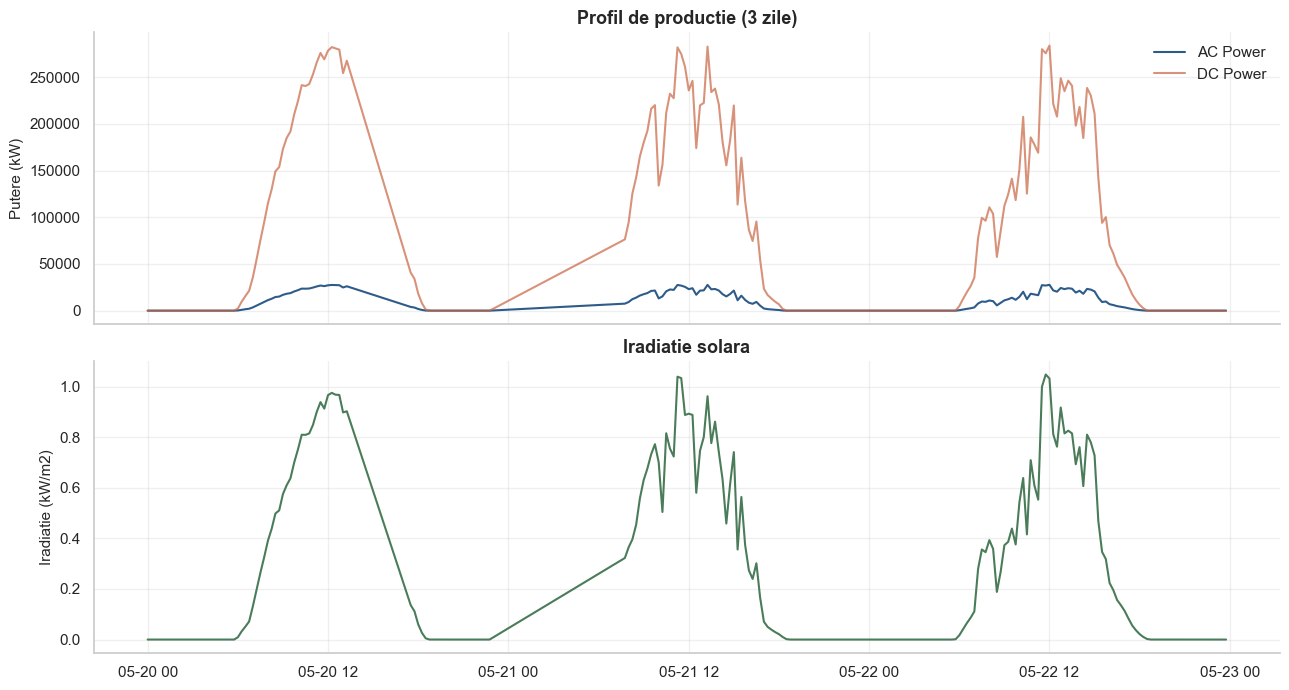

In [5]:
# Selectam 3 zile consecutive
sample = df.loc['2020-05-20':'2020-05-22']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(sample.index, sample['AC_POWER'], color=PALETA['primary'], label='AC Power')
axes[0].plot(sample.index, sample['DC_POWER'], color=PALETA['secondary'], label='DC Power', alpha=0.7)
axes[0].set_ylabel('Putere (kW)')
axes[0].set_title('Profil de productie (3 zile)')
axes[0].legend()

axes[1].plot(sample.index, sample['IRRADIATION'], color=PALETA['tertiary'])
axes[1].set_ylabel('Iradiatie (kW/m2)')
axes[1].set_title('Iradiatie solara')

plt.tight_layout()
plt.show()

**Interpretare:** profilul este clar - 0 puteri noaptea, urcare rapida la rasarit, varf la pranz, scadere la apus. AC_POWER < DC_POWER este normal si reflecta pierderile la conversie in invertor (eficienta tipica 95-98%). Iradiatia urmeaza acelasi profil ca puterea, dar cu valori mai stabile (sigma mai mica).

## 4. Relatia iradiere -> putere

Daca relatia este aproape liniara, un model simplu poate fi suficient. Daca se vede o curba de saturatie sau influenta temperaturii, avem nevoie de model neliniar.

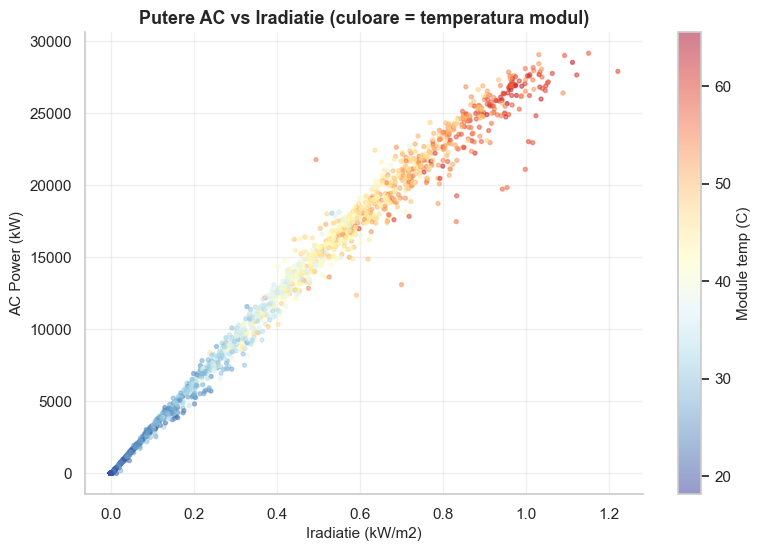

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    df['IRRADIATION'], df['AC_POWER'],
    c=df['MODULE_TEMPERATURE'], cmap='RdYlBu_r',
    alpha=0.5, s=8,
)
ax.set_xlabel('Iradiatie (kW/m2)')
ax.set_ylabel('AC Power (kW)')
ax.set_title('Putere AC vs Iradiatie (culoare = temperatura modul)')
plt.colorbar(scatter, label='Module temp (C)')
plt.show()

**Interpretare:** relatia iradiere -> putere este puternic liniara, dar cu dispersie pe verticala care depinde de temperatura modulului. Cand modulul este foarte cald (rosu), eficienta scade - se vede un nor de puncte sub linia ideala. Acest fenomen este bine cunoscut in fizica panourilor: temperatura inalta reduce tensiunea de iesire.

## 5. Matrice de corelatii

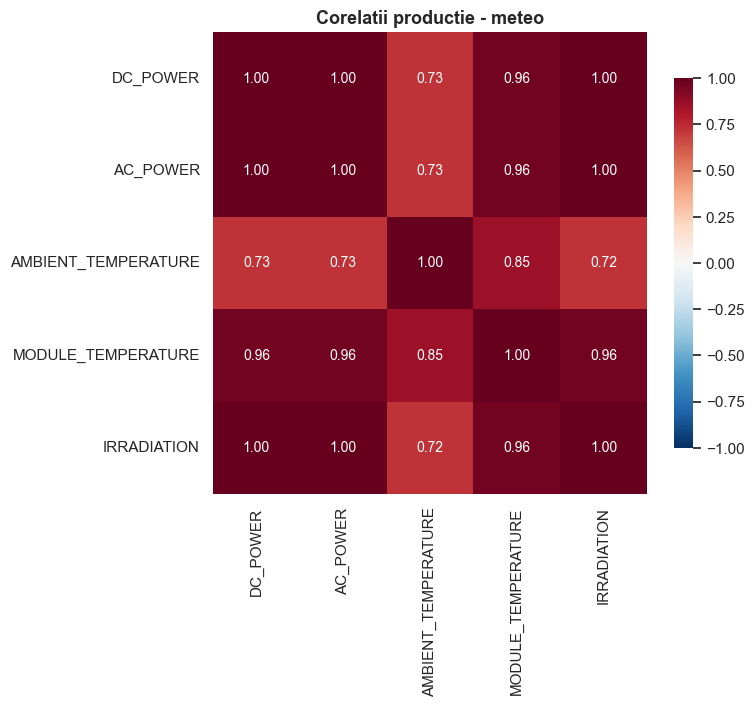

In [7]:
key_cols = ['DC_POWER', 'AC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
ax = plot_correlation_heatmap(df[key_cols], title='Corelatii productie - meteo', figsize=(7, 6))
plt.show()

**Interpretare:** AC_POWER are corelatie aproape perfecta cu DC_POWER (0.99) - relatie aproape lineara prin invertor. Iradiatia este principalul predictor (corelatie ~0.99 cu puterea). Temperatura modulului este foarte corelata cu iradiatia (panoul se incalzeste de la soare), deci atentie la multicoliniaritate cand le folosim ambele ca features.

## 6. Eficienta de conversie DC -> AC

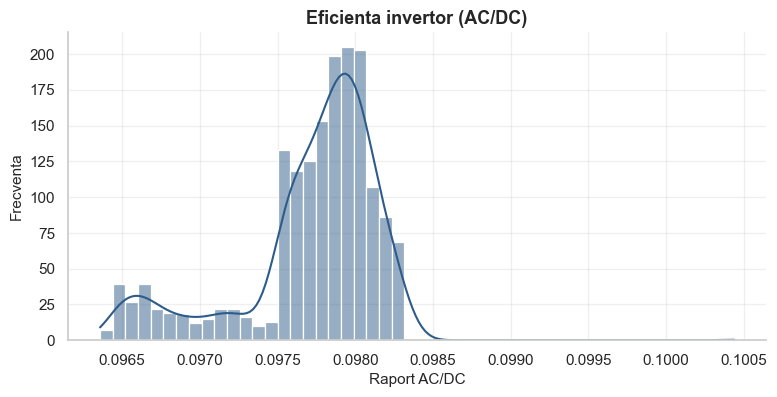

Eficienta medie: 0.0977
Eficienta mediana: 0.0978


In [8]:
# Calculam eficienta doar pentru orele cu productie
active = df[df['DC_POWER'] > 100].copy()
active['efficiency'] = active['AC_POWER'] / active['DC_POWER']

ax = plot_distribution(active['efficiency'], title='Eficienta invertor (AC/DC)', xlabel='Raport AC/DC')
plt.show()

print(f'Eficienta medie: {active["efficiency"].mean():.4f}')
print(f'Eficienta mediana: {active["efficiency"].median():.4f}')

**Interpretare:** eficienta este foarte concentrata in jurul a 0.10 - acest raport e suspect de mic pentru un invertor real (ar trebui ~0.97). Cel mai probabil DC_POWER este raportata in alta unitate decat AC_POWER (ex: DC in W si AC in kW, diferenta de 1000x). Vom investiga la pasul de preprocesare si vom rescala daca e cazul; pentru predictia AC_POWER nu este o problema majora pentru ca relatia este oricum stabila.

## 7. Concluzii si pasi urmatori

**Ce am invatat:**
1. Datele acopera 34 zile cu pas de 15 min, agregate peste 22 invertoare.
2. AC_POWER este aproape liniar dependenta de iradiatie, cu corectie de la temperatura modulului.
3. Profilul zilnic este foarte regulat (clopot in jurul pranzului).
4. Posibila inconsistenta de unitate intre DC si AC - de verificat la preprocesare.

**Pasi urmatori:**
- Verificare unitate DC vs AC; rescalare daca e necesar.
- Feature engineering: ora zilei (cosinus/sinus), zi a anului, indicator ploaie / soare.
- Model predictiv pentru AC_POWER cu iradiatie + temp modul ca features principale.
- Comparatie modele: regresie liniara (baseline), Random Forest, XGBoost, posibil LSTM.
- Optimizare neliniara: cum gestionam stocarea cand exces > consum.

Acest set este interesant datorita relatiei fizice clare - permite o validare buna a modelului impotriva intuitiei inginerersti.